In [28]:

import os
import sys
import numpy as np
import seaborn as sns
import pandas as pd

from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.patches as patches
from matplotlib_scalebar.scalebar import ScaleBar


In [10]:
import skeliner as sk

In [11]:
import sys

sys.path.append("../utils")

import data_io

In [4]:
sk.__version__

'0.2.6'

# setup

In [6]:
cm = 1/2.54  # centimeters in inches
plt.style.use('paper.mplstyle')

In [19]:
### manually choose cells for example plot ###
example_cells = {
"A17": "720575940555793382",
"nNOS-1": "720575940562504921" ,
"A2" : "720575940562476215" ,
"Other": "720575940556857319"}

cmap = { "RBC" : "#0C7C59",
         "A2": "#134D7C",
         "A17":  "#32A9DE",
         "nNOS-1": "#B1DEF2",
         "Other":"#1D74B9" }



# load data

In [31]:
config = data_io.get_data_config()
version = config.get("version_rb", None)
skel_dir = config.get("skel_dir", None)

In [21]:
assert os.path.isdir(skel_dir), skel_dir

In [25]:
skel_files = {'A17': f'{skel_dir}/{example_cells['A17']}.npz',
              'A2': f'{skel_dir}/{example_cells['A2']}.npz',
              'nNOS-1': f'{skel_dir}/{example_cells['nNOS-1']}.npz',
              'Other': f'{skel_dir}/{example_cells['Other']}.npz'}
 

In [26]:
skel_files

{'A17': '../data/swc/720575940555793382.npz',
 'A2': '../data/swc/720575940562476215.npz',
 'nNOS-1': '../data/swc/720575940562504921.npz',
 'Other': '../data/swc/720575940556857319.npz'}

In [6]:
username = !whoami
username = username[0]
username

'sebert'

In [7]:
home_directory = os.path.expanduser("~")
home_directory


'/gpfs01/berens/user/sebert'

In [8]:
config_file = f'{home_directory}/datajoint/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'

In [9]:
schema_name = "ageuler_eyewire_ii_morph"

In [10]:
dj.config.load(config_file)
dj.config['schema_name'] = schema_name
print("schema_name:", dj.config['schema_name'])
dj.conn()

[2026-05-15 10:48:31,804][INFO]: DataJoint is configured from /gpfs01/berens/user/sebert/datajoint/dj_sebert_conf.json
[2026-05-15 10:48:31,851][INFO]: DataJoint 0.14.7 connected to sebert@172.25.240.200:3306


schema_name: ageuler_eyewire_ii_morph


DataJoint connection (connected) sebert@172.25.240.200:3306

In [11]:
# TODO install this as a package ??
sys.path.append('/gpfs01/berens/user/sebert/Repositories/eyewire2_datajoint')
from eyewire2_datajoint.datajoint.schemas.morph_schema import *

In [12]:
morph_schema.activate(schema_name, create_schema=False, create_tables=True)

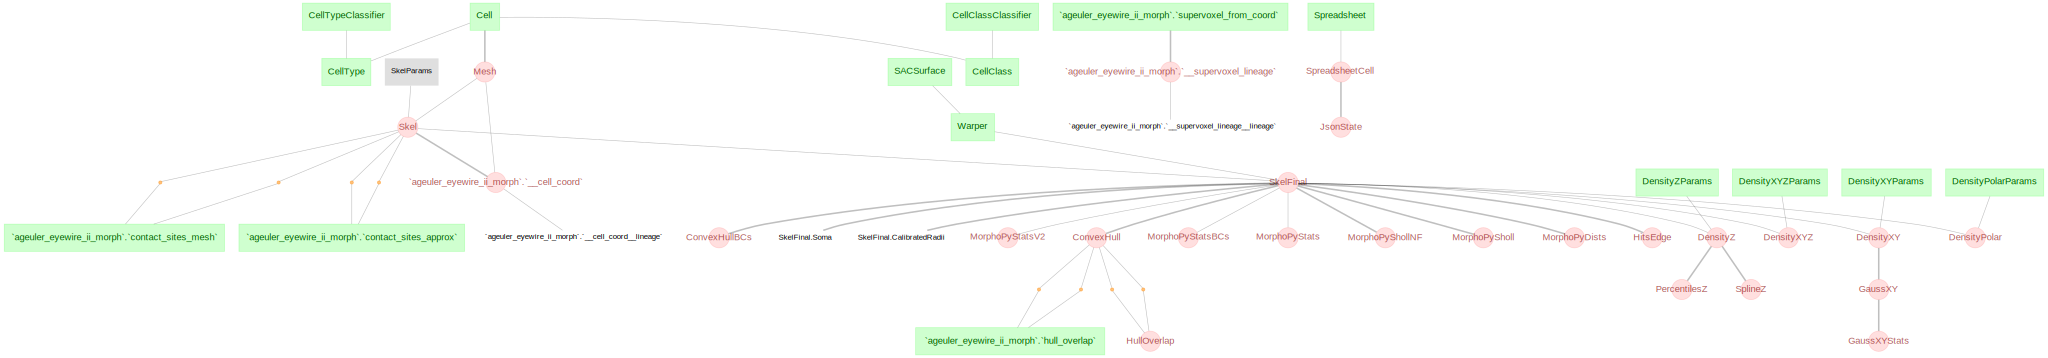

In [13]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    display(dj.ERD(morph_schema))

In [14]:
skel_files = {}
for exmpl in list(example_cells.keys()):
    skel_file = (SkelFinal & f'cell = {example_cells[exmpl]}').fetch("skel_file")[0]
    # skel = sk.io.load_npz(skel_file)
    skel_files[exmpl] = skel_file


mesh_files = {}
for exmpl in list(example_cells.keys()):
    mesh_file = (Mesh & f'cell = {example_cells[exmpl]}').fetch("mesh_file")[0]
    # skel = sk.io.load_npz(skel_file)
    mesh_files[exmpl] = mesh_file


# figure

In [32]:
fig_dir = f'../figures/connectivity/v{version}'
os.makedirs(fig_dir, exist_ok=True)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


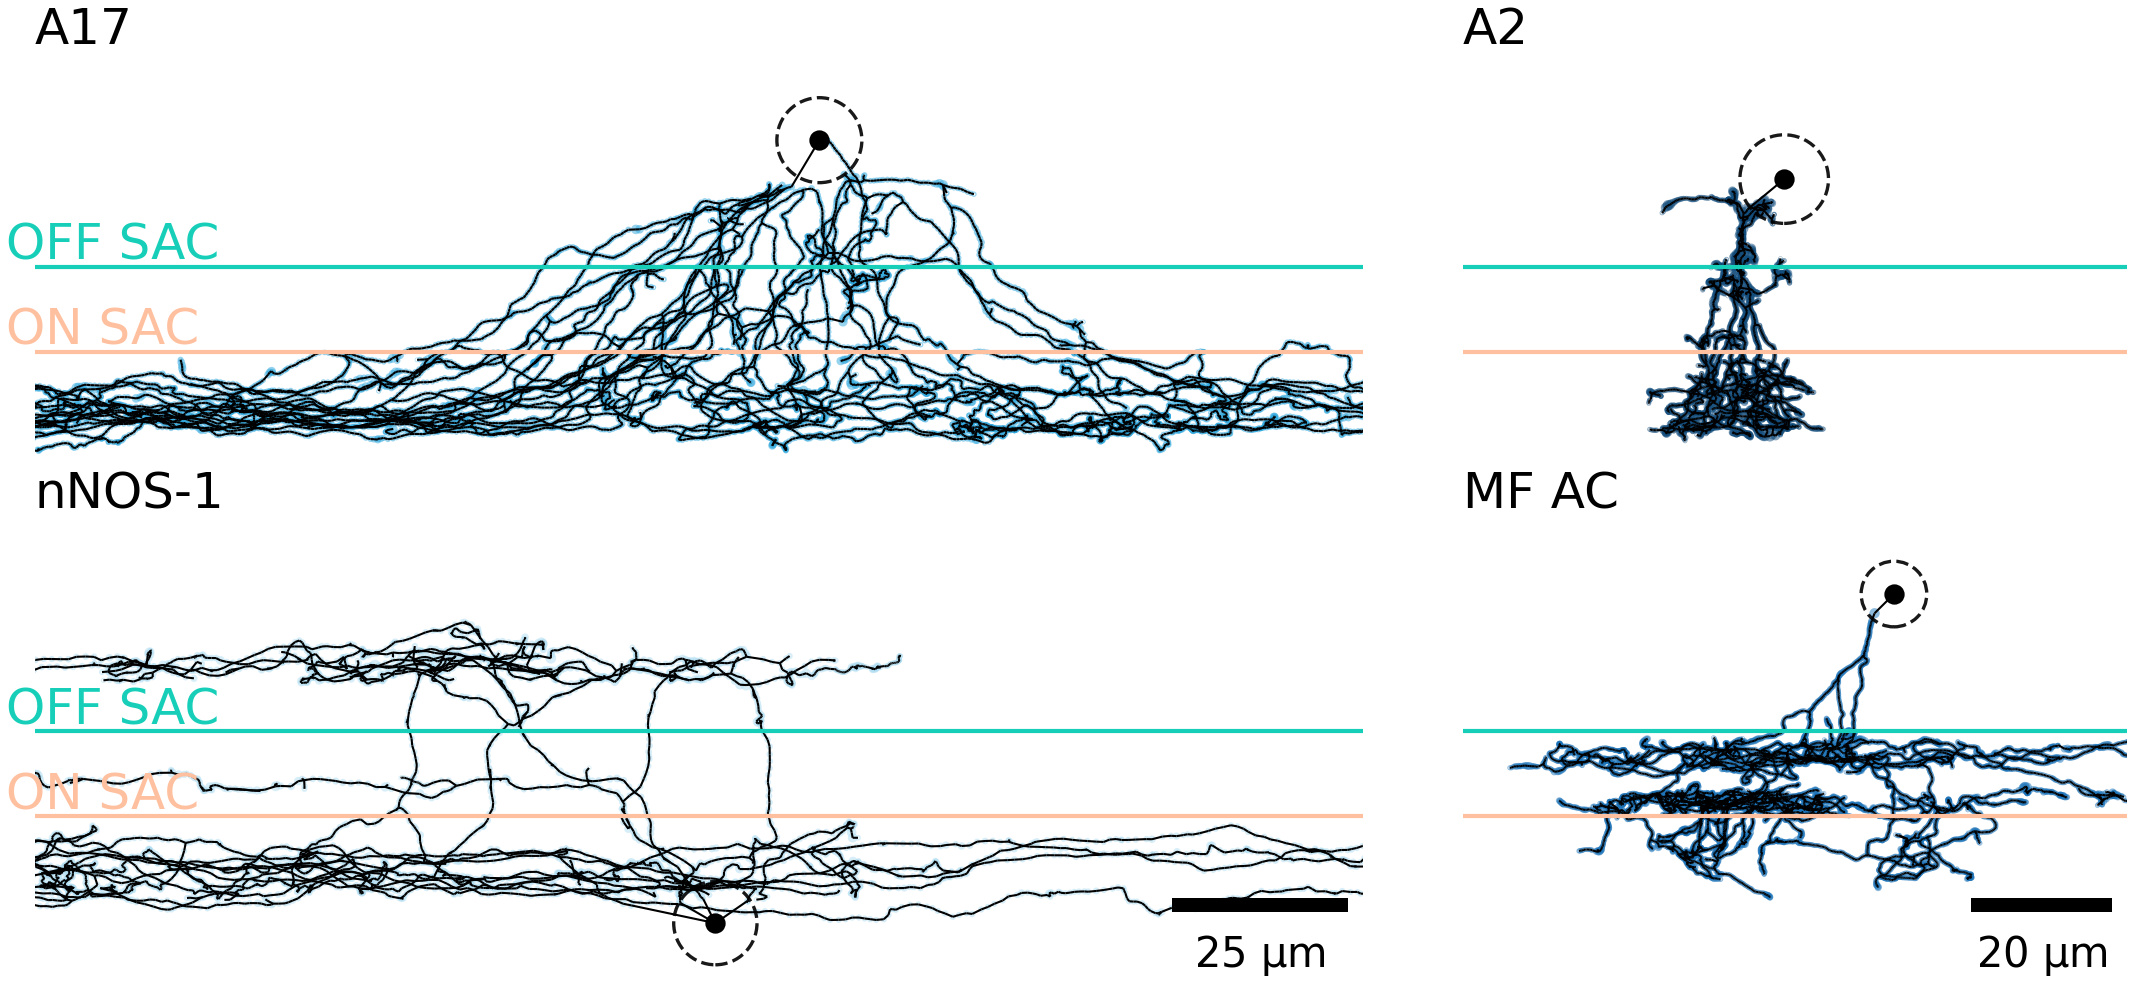

In [33]:
ix = 0  # x-imension to plot (x-axis)
iy = 2  # y dimension to plot (z-axis)



on_sac_pos = 0.0
off_sac_pos = 12.0

on_sac_color = "#FFC09F"
off_sac_color = "#17CFB9"


fig = plt.figure(figsize=(9, 4))

fig.subplots_adjust(wspace=0.1, hspace = 0.01)
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[2, 1],
    height_ratios=[1, 1]
)

axes_spec = [gs[0, 0], gs[1, 0], gs[0, 1], gs[1, 1]]

ylim = (-25, 40)
xlims = [(500, 900), (400, 800), (600, 800), (600, 800)]


# create first axis explicitly (shared y-axis reference)
ax0 = fig.add_subplot(axes_spec[0], frameon=False)
# ax0.set_rasterized(True)
# ax0.set_aspect("equal", adjustable="datalim")

for i, ct in enumerate(example_cells.keys()):

    segid = example_cells[ct]
    col = cmap[ct]

    skel_file = skel_files[ct]
    # mesh_file = f"{path_meshes}/{segid}.obj"

    skel = sk.io.load_npz(skel_file)
    # mesh = sk.io.load_mesh(mesh_file)

    if i == 0:
        ax = ax0
    else:
        ax = fig.add_subplot(
            axes_spec[i],
            sharey=ax0,
            frameon=False
        )

  
   
    ax.set_xlim(xlims[i])
    ax.set_ylim(ylim)


    


    # 2d skeleton nodes
    v = sk.plot.vis2d._project(skel.nodes, ix,iy)
    
    radius_metric = skel.recommend_radius()[0]
    rr = skel.radii[radius_metric] 
    sizes, _ppd = sk.plot.vis2d._radii_to_sizes(rr, ax)

    ax.scatter(v[1:,0], v[1:,1], s = sizes[1:],
               facecolors = 'none', edgecolors = col, alpha = 0.5, zorder = -2000)


    # edges
    seg_start = v[skel.edges[:,0]]
    seg_end = v[skel.edges[:,1]]
    segments = np.stack((seg_start, seg_end), axis=1)

    lc = LineCollection(
        segments.tolist(),
        colors='k',
        linewidths=0.5,
        alpha=1,
        zorder = -1000
    )
    ax.add_collection(lc)

    
    # soma
    c_xy = sk.plot.vis2d._project(skel.nodes[[0]], ix, iy).ravel()
    ax.scatter(*c_xy, color= 'k', s=15, zorder=3)
    


    soma_circle = patches.Circle(
        c_xy,
        skel.soma.equiv_radius * 1.0,
        facecolor="none",
        edgecolor='k',
        linewidth=0.8,
        linestyle="--",
        alpha=0.9,
    )
    ax.add_patch(soma_circle)


    
    #   # 
    # ax.set_xlabel("")
    # ax.set_ylabel("")
    
    


    # reference lines
    ax.axhline(on_sac_pos, color = on_sac_color)
    ax.axhline(off_sac_pos, color= off_sac_color)


    

    if i == 0:  # bottom-left panel
        ax.text(602,1,'ON SAC', color = on_sac_color,fontsize = 12)
        ax.text(602,13,'OFF SAC', color = off_sac_color,fontsize = 12)

    if i == 1:  # bottom-left panel
        ax.text(502,1,'ON SAC', color = on_sac_color,fontsize = 12)
        ax.text(502,13,'OFF SAC', color = off_sac_color,fontsize = 12)

    

    # add scalebar to one panel only
    if i == 1 or i == 3:  # bottom-left panel
        scalebar = ScaleBar(
            dx=1e-3,          # matches scale argument above
            units="mm",
            length_fraction=0.25,
            height_fraction=0.03,
            loc = 'lower right',
            # bbox_to_anchor = (-20, 500),
            frameon=False)
        ax.add_artist(scalebar)

    ax.set_rasterization_zorder(0)
    ax.set_aspect('equal', adjustable = 'datalim')

    if ct == "Other":
        ct = "MF AC"
    if ct == "A1":
        ct = "nNOS-1 AC"
    ax.set_title(ct, loc="left", fontsize = 12)
    ax.set_axis_off()
    ax.set_xlim(xlims[i])
    ax.set_ylim(ylim)


plt.show()

fig.savefig(f'{fig_dir}/fig8__E_rbcexamples.svg',dpi = 300)
